# 📊 Teste de Acurácia - Emotion Service

Notebook simples para medir acurácia e latência usando FER-2013.


In [ ]:
# Instalar dependências necessárias
# !pip install datasets pillow requests scikit-learn matplotlib seaborn


In [7]:
import requests
import time
import io
from PIL import Image
import numpy as np
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações
SERVICE_URL = "http://localhost:8003"
SAMPLE_SIZE = 100  # Número de amostras a testar

# Mapeamento de emoções FER-2013 -> DeepFace
emotion_mapping = {
    0: "angry",
    1: "disgust", 
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

print(f"🎯 Configuração:")
print(f"   Serviço: {SERVICE_URL}")
print(f"   Amostras: {SAMPLE_SIZE}")


🎯 Configuração:
   Serviço: http://localhost:8003
   Amostras: 100


In [8]:
# Verificar se o serviço está rodando
def check_service():
    try:
        response = requests.get(f"{SERVICE_URL}/health", timeout=5)
        if response.status_code == 200:
            print("✅ Serviço está rodando")
            return True
        else:
            print(f"❌ Serviço retornou status: {response.status_code}")
            return False
    except:
        print("❌ Serviço não está disponível")
        print("💡 Execute: docker compose -f docker-compose.dev.yml up emotion-service -d")
        return False

check_service()


✅ Serviço está rodando


True

## Load FER-2013

In [9]:
# from datasets import load_dataset
# import numpy as np
# from PIL import Image
# import io

# print("📥 Carregando dataset FER-2013...")
# dataset = load_dataset("raf-db", split="test", trust_remote_code=True)
# print("✅ RAF-DB carregado")
# SAMPLE_SIZE = 100

# sample_indices = [int(i) for i in np.random.choice(len(dataset), min(SAMPLE_SIZE, len(dataset)), replace=False)]
# samples = [dataset[i] for i in sample_indices]

# print(f"✅ Carregadas {len(samples)} amostras do FER-2013")
# print(f"📊 Primeiro exemplo: {samples[0]['labels']}")

# # img = Image.open(io.BytesIO(samples[0]["img_bytes"]))
# # img.show()


### Load JAFFE

In [ ]:
import os
from PIL import Image
import pandas as pd

# Mapas dos códigos para emoções
label_map = {
    'AN': 'angry', 'DI': 'disgust', 'FE': 'fear', 'HA': 'happy',
    'SA': 'sad', 'SU': 'surprise', 'NE': 'neutral'
}

img_dir = './assets/jaffe/jaffe'  # Pasta onde extraiu o dataset
imgs, labels = [], []

for fname in os.listdir(img_dir):
    if fname.lower().endswith('.tiff'):
        label_code = fname.split('.')[1][:2].upper()  # Ex: 'KA.HA1.31.tiff' -> 'HA'
        if label_code in label_map:
            img = Image.open(os.path.join(img_dir, fname)).convert('L').resize((224,224))
            imgs.append(img)
            labels.append(label_map[label_code])

# Crie um DataFrame para manipulação fácil
df_jaffe = pd.DataFrame({'image': imgs, 'emotion_label': labels})

print(f"✅ JAFFE carregado: {len(df_jaffe)} imagens")
print("📊 Rótulos:", df_jaffe['emotion_label'].value_counts())

✅ JAFFE carregado: 213 imagens
📊 Rótulos: emotion_label
fear        32
sad         31
happy       31
anger       30
surprise    30
neutral     30
disgust     29
Name: count, dtype: int64


## Load CK+

In [22]:
import pandas as pd
import numpy as np
from PIL import Image

# Caminho do CSV
csv_path = 'assets/ckplus/ckextended.csv'

# Mapeamento dos índices para labels (ajuste se necessário)
emotion_map = {
    0: 'angry',
    1: 'disgust',
    2: 'fear',
    3: 'happy',
    4: 'sad',
    5: 'surprise',
    6: 'neutral',
    7: 'contempt'
}

# Carrega o CSV
df = pd.read_csv(csv_path)

imgs, labels = [], []

for idx, row in df.iterrows():
    # Reconstrói a imagem a partir dos pixels (formato 48x48, igual ao FER-2013)
    pixels = np.array([int(p) for p in row['pixels'].split()], dtype=np.uint8)
    img = Image.fromarray(pixels.reshape((48, 48)), mode='L').resize((224, 224))
    imgs.append(img)
    labels.append(emotion_map[row['emotion']])

# DataFrame final pronto para análise
df_ckplus = pd.DataFrame({'image': imgs, 'emotion_label': labels})
print(f"✅ CK+ carregado: {len(df_ckplus)} imagens")
print("📊 Rótulos:", df_ckplus['emotion_label'].value_counts())

/tmp/ipykernel_7812/2761559491.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels.reshape((48, 48)), mode='L').resize((224, 224))


✅ CK+ carregado: 920 imagens
📊 Rótulos: emotion_label
neutral     593
surprise     83
happy        69
disgust      59
angry        45
sad          28
fear         25
contempt     18
Name: count, dtype: int64


In [31]:
# Função para predizer emoção
def predict_emotion(image):
    # Converter imagem para bytes
    img_buffer = io.BytesIO()
    image.save(img_buffer, format='JPEG')
    img_bytes = img_buffer.getvalue()
    
    # Fazer requisição
    files = {"file": ("test.jpg", img_bytes, "image/jpeg")}
    
    start_time = time.time()
    response = requests.post(f"{SERVICE_URL}/analyze-facial-expression", files=files, timeout=10)
    end_time = time.time()
    
    response_time = (end_time - start_time) * 1000  # em ms
    
    if response.status_code == 200:
        data = response.json()
        emotion = data.get("dominant_emotion", "neutral")
        confidence = data.get("confidence", 0.0)
        return emotion, confidence, response_time
    else:
        return "neutral", 0.0, response_time

print("✅ Função de predição criada")


✅ Função de predição criada


In [33]:
## Predic JAFFE

import numpy as np

# Defina o número de amostras desejado
N_SAMPLES = 213

# Seleciona 100 amostras aleatórias do DataFrame (sem repetição)
df = df_jaffe.sample(n=min(N_SAMPLES, len(df_jaffe)), random_state=42).reset_index(drop=True)

# N_PER_CLASS = 20   # Por exemplo, para ter ~98 amostras em 7 classes
# df = (
#     df_ckplus
#     .groupby('emotion_label', group_keys=False)
#     .apply(lambda x: x.sample(n=min(N_PER_CLASS, len(x)), random_state=42))
#     .reset_index(drop=True)
# )

print(df['emotion_label'].value_counts())
print(f"Total: {len(df)} amostras estratificadas")

print(f"🧪 Iniciando teste de acurácia no CK+ ({N_SAMPLES} amostras aleatórias)...")

true_labels = []
predicted_labels = []
response_times = []
confidences = []

for i, row in df.iterrows():
    image = row['image'].convert('RGB')  # JAFFE já vem 224x224 acima
    true_emotion = row['emotion_label']

    pred_emotion, confidence, response_time = predict_emotion(image)

    true_labels.append(true_emotion)
    predicted_labels.append(pred_emotion)
    response_times.append(response_time)
    confidences.append(confidence)
    
    correct = "✅" if pred_emotion == true_emotion else "❌"
    print(f"{i+1:3d}/{len(df)}: {true_emotion:8s} → {pred_emotion:8s} {correct} (conf: {confidence:.2f}, {response_time:.0f}ms)")

print("\n✅ Teste concluído no CK+!")

emotion_label
fear        32
sad         31
happy       31
neutral     30
surprise    30
anger       30
disgust     29
Name: count, dtype: int64
Total: 213 amostras estratificadas
🧪 Iniciando teste de acurácia no CK+ (213 amostras aleatórias)...
  1/213: sad      → sad      ✅ (conf: 0.91, 5216ms)
  2/213: fear     → neutral  ❌ (conf: 0.63, 4865ms)


KeyboardInterrupt: 

In [28]:
## Predict FER-2013

# for i, sample in enumerate(samples):
#     # Extrair imagem (img_bytes → PIL.Image)
#     if isinstance(sample['img_bytes'], bytes):
#         image = Image.open(io.BytesIO(sample['img_bytes']))
#     else:
#         image = sample['image']   # Caso já seja PIL.Image

#     # Pega o rótulo verdadeiro
#     true_emotion_id = sample['emotion_label']
#     true_emotion = emotion_mapping[true_emotion_id]
    
#     # Redimensionar para 224x224
#     image = image.convert('RGB').resize((224, 224))
    
#     # Predizer emoção
#     pred_emotion, confidence, response_time = predict_emotion(image)
    
#     # Armazenar resultados
#     true_labels.append(true_emotion)
#     predicted_labels.append(pred_emotion)
#     response_times.append(response_time)
#     confidences.append(confidence)
    
#     # Status
#     correct = "✅" if pred_emotion == true_emotion else "❌"
#     print(f"{i+1:3d}/{len(samples)}: {true_emotion:8s} → {pred_emotion:8s} {correct} (conf: {confidence:.2f}, {response_time:.0f}ms)")


In [25]:
# Calcular métricas
accuracy = accuracy_score(true_labels, predicted_labels)
avg_response_time = np.mean(response_times)
p95_response_time = np.percentile(response_times, 95)
avg_confidence = np.mean(confidences)

print("\n" + "="*60)
print("📊 RESULTADOS FINAIS")
print("="*60)
print(f"🎯 Acurácia: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"⚡ Tempo médio: {avg_response_time:.1f}ms")
print(f"📈 P95 tempo: {p95_response_time:.1f}ms")
print(f"🎭 Confiança média: {avg_confidence:.3f}")
print(f"📊 Amostras testadas: {len(df)}")
print(f"✅ Predições corretas: {sum(1 for t, p in zip(true_labels, predicted_labels) if t == p)}")
print(f"🚀 Throughput: ~{1000/avg_response_time:.1f} req/s")



📊 RESULTADOS FINAIS
🎯 Acurácia: 0.418 (41.8%)
⚡ Tempo médio: 4555.7ms
📈 P95 tempo: 5132.1ms
🎭 Confiança média: 0.797
📊 Amostras testadas: 158
✅ Predições corretas: 66
🚀 Throughput: ~0.2 req/s


In [26]:
# Relatório detalhado por emoção
print("\n📈 RELATÓRIO POR EMOÇÃO:")
print(classification_report(true_labels, predicted_labels, digits=3))



📈 RELATÓRIO POR EMOÇÃO:
              precision    recall  f1-score   support

       angry      0.240     0.300     0.267        20
    contempt      0.000     0.000     0.000        18
     disgust      1.000     0.100     0.182        20
        fear      0.250     0.100     0.143        20
       happy      0.541     1.000     0.702        20
     neutral      0.342     0.650     0.448        20
         sad      0.351     0.650     0.456        20
    surprise      0.909     0.500     0.645        20

    accuracy                          0.418       158
   macro avg      0.454     0.412     0.355       158
weighted avg      0.460     0.418     0.360       158



/home/toni/projects/empath-ia/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/toni/projects/empath-ia/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/toni/projects/empath-ia/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

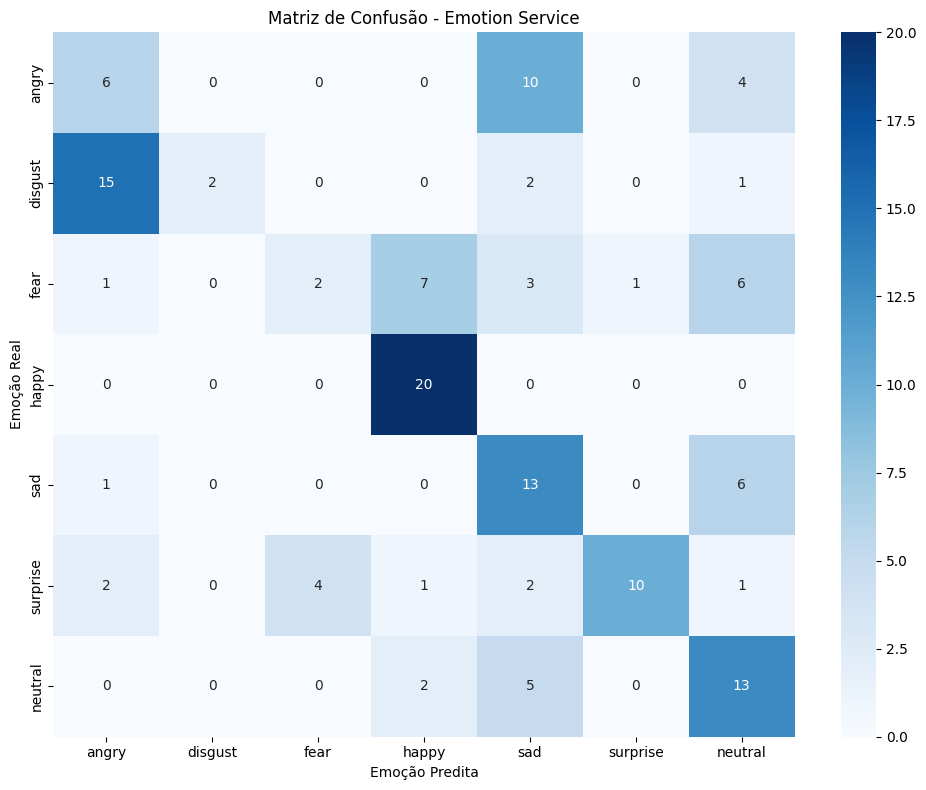

In [28]:
# Matriz de confusão
emotions = list(emotion_mapping.values())
cm = confusion_matrix(true_labels, predicted_labels, labels=emotions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('Matriz de Confusão - Emotion Service')
plt.xlabel('Emoção Predita')
plt.ylabel('Emoção Real')
plt.tight_layout()
plt.show()


In [ ]:
# Gráfico de tempos de resposta
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(response_times, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(avg_response_time, color='red', linestyle='--', label=f'Média: {avg_response_time:.1f}ms')
plt.axvline(p95_response_time, color='orange', linestyle='--', label=f'P95: {p95_response_time:.1f}ms')
plt.xlabel('Tempo de Resposta (ms)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Tempos de Resposta')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(response_times)
plt.ylabel('Tempo de Resposta (ms)')
plt.title('Box Plot - Tempos de Resposta')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Estatísticas de performance detalhadas
print("\n📊 ESTATÍSTICAS DE PERFORMANCE:")
print(f"   Tempo Médio: {np.mean(response_times):.1f}ms")
print(f"   Tempo Mediano: {np.median(response_times):.1f}ms")
print(f"   Desvio Padrão: {np.std(response_times):.1f}ms")
print(f"   Tempo Mínimo: {np.min(response_times):.1f}ms")
print(f"   Tempo Máximo: {np.max(response_times):.1f}ms")
print(f"   P90: {np.percentile(response_times, 90):.1f}ms")
print(f"   P95: {np.percentile(response_times, 95):.1f}ms")
print(f"   P99: {np.percentile(response_times, 99):.1f}ms")

print("\n🎯 ANÁLISE FINAL:")
if accuracy >= 0.6:
    print("   ✅ Acurácia excelente para produção")
elif accuracy >= 0.4:
    print("   🟡 Acurácia moderada - considerar melhorias")
else:
    print("   🔴 Acurácia baixa - verificar configurações do modelo")

if avg_response_time <= 100:
    print("   ⚡ Performance excelente para tempo real")
elif avg_response_time <= 500:
    print("   ✅ Performance adequada para tempo real")
else:
    print("   ⚠️ Performance pode ser otimizada")

print(f"\n🎉 Teste completo finalizado!")
